In [2]:
import msprime, tskit
import numpy as np
import gaiapy as gp
import pandas as pd
from scipy.spatial.distance import pdist, squareform

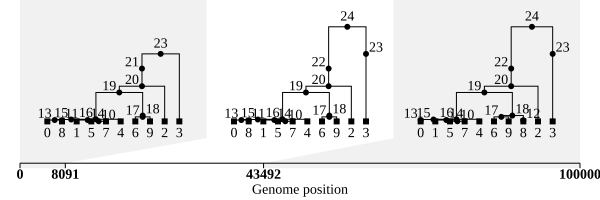

In [ ]:
#test = msprime.sim_ancestry(3, recombination_rate=0.1, sequence_length=2, record_full_arg=True, random_seed=42)

#simp_test = test.simplify()
#ext_test = simp_test.extend_haplotypes()

ts = tskit.load("/home/islar/bradburdlab/tree_project/unary_project/tree-S1.1-R2.trees")

tsimp = ts.simplify()
tsext = tsimp.extend_haplotypes()
#test.draw_svg()


In [3]:
def locations(ts):
    nodes = ts.nodes()
    locs_array = []
    for node in nodes:
        if node.individual != -1:
            ind = ts.individual(node.individual)
            x = ind.location[0]
            y = ind.location[1]
            is_sample = node.is_sample()
            locs_array.append(node.id)
            locs_array.append(is_sample)
            locs_array.append(x)
            locs_array.append(y)
        
    locs_array = np.array(locs_array)
    locs = locs_array.reshape(-1, 4)
    return locs

#locations(tsimp)

In [4]:
def findUnary(ts):
    unary_nodes = np.zeros(ts.num_nodes) # binary vector specifying if a node is unary or not anywhere on the tree sequence
    for tree in ts.trees():
        num_children = tree.num_children_array[:ts.num_nodes]
        is_unary = num_children == 1
        for i, condition in enumerate(is_unary):
            if is_unary[i] == True:
                unary_nodes[i] = 1
    mask = unary_nodes == 1
    #mask, unary_nodes[mask]
    unary_list = np.where(mask)
    unary_indices = unary_list[0]
    return unary_indices

In [5]:
#def getAccOut(ts, unary_indices, outPrefix):
def small_getAccOut(ts, unary_indices, samples, ancestors, everything, outPrefix):
    # tqdm - package to test timing of things 

    sample_locations = samples # comment this out when not usign test data set 
    ancestor_locations = ancestors

    sample_centroid = np.mean(sample_locations[:, 1:], axis=0)
    # print(sample_centroid)
    mpr = gp.quadratic_mpr(ts, sample_locations)
    map_x = gp.quadratic_mpr_minimize(mpr)
    
    is_unary = np.isin(everything[:, 0], unary_indices) # is_unary = np.isin(locs[:, 0], unary_indices)
    is_ancestor = np.isin(everything[:, 0], ancestor_locations[:, 0])
    target_nodes = is_unary & is_ancestor 
   

    target_locations = everything[target_nodes][:, [0, 1, 2]]

    e = np.sqrt(np.sum((map_x[target_nodes] - target_locations[:, 1:2])**2, axis=1)) / np.max(pdist(sample_locations[:, 1:2]))
    
    dist_from_sample_centroid0 = np.sqrt(np.sum((target_locations[:, 1:3] - sample_centroid)**2, axis=1))
    dist_from_sample_centroid = np.sqrt(np.sum((map_x[target_nodes] - sample_centroid)**2, axis=1))
    
    target_node_ids = everything[target_nodes, 0]
    target_node_times = ts.nodes_time[target_nodes]

    ancestor_df = pd.DataFrame({
        'node_id': target_node_ids,
        'node_time': target_node_times,
        'error': e,
        'dist_from_sample_centroid0': dist_from_sample_centroid0,
        'dist_from_sample_centroid': dist_from_sample_centroid
    })

    ancestor_df.to_csv(f"{outPrefix}_ancestor-estimates.csv",
                      mode='a', header=False, index=False)
    
    return ancestor_df

In [ ]:
def big_getAccOut(ts, unary_indices, outPrefix, sigma, rep):
    # tqdm - package to test timing of things 

    locs = locations(ts)
    sample_locations = locs[locs[:, 1] == 1][:, [0, 2, 3]]
    ancestor_locations = locs[locs[:, 1] != 1][:, [0, 2, 3]]


    sample_centroid = np.mean(sample_locations[:, 1:], axis=0)
    # print(sample_centroid)
    mpr = gp.quadratic_mpr(ts, sample_locations)
    map_x = gp.quadratic_mpr_minimize(mpr)
    
    is_unary = np.isin(locs[:, 0], unary_indices)
    is_ancestor = np.isin(locs[:, 0], unary_indices)
    target_nodes = is_unary & is_ancestor 
   
    target_locations = locs[target_nodes][:, [0, 2, 3]]

    e = np.sqrt(np.sum((map_x[target_nodes] - target_locations[:, 1:2])**2, axis=1)) / np.max(pdist(sample_locations[:, 1:2]))
    
    dist_from_sample_centroid0 = np.sqrt(np.sum((target_locations[:, 1:3] - sample_centroid)**2, axis=1))
    dist_from_sample_centroid = np.sqrt(np.sum((map_x[target_nodes] - sample_centroid)**2, axis=1))
    
    target_node_ids = locs[target_nodes, 0]
    target_node_times = ts.nodes_time[target_nodes]

    ancestor_df = pd.DataFrame({
        'sigma': np.repeat(sigma, target_node_ids.shape[0]),
        'rep': np.repeat(rep, target_node_ids.shape[0]),
        'node_id': target_node_ids,
        'node_time': target_node_times,
        'error': e,
        'dist_from_sample_centroid0': dist_from_sample_centroid0,
        'dist_from_sample_centroid': dist_from_sample_centroid
    })

    ancestor_df.to_csv(f"{outPrefix}_ancestor-estimates.csv",
                      mode='a', header=False, index=False)
    
    return ancestor_df

In [6]:
#test = msprime.sim_ancestry(3, recombination_rate=0.1, sequence_length=2, record_full_arg=True, random_seed=42)
#msprime.sim_ancestry(5, sequence_length=1e5, recombination_rate=1e-6, record_full_arg=True)

#simp_test = test.simplify()
#ext_test = simp_test.extend_haplotypes()

ts = tskit.load("/home/islar/bradburdlab/tree_project/unary_project/tree-S0.5-R4.trees")

tsimp = ts.simplify()
tsext = tsimp.extend_haplotypes()
#test.draw_svg()

unary_indices_big = findUnary(tsext)
getAccOut(tsext, unary_indices_big, "S0.5-R4_ext")
getAccOut(tsimp, unary_indices_big, "S0.5-R4_simp")


,sigma,rep,node_id,node_time,error,dist_from_sample_centroid0,dist_from_sample_centroid
0,0.2,0,1672.0,1.0,3.263977,48.982138,49.618429
1,0.2,0,1674.0,1.0,3.260151,49.606670,49.162625
2,0.2,0,1676.0,1.0,3.259665,48.523813,47.864396
3,0.2,0,1679.0,1.0,3.131054,24.697296,24.638085
4,0.2,0,1680.0,1.0,3.122220,24.160199,24.244365
...,...,...,...,...,...,...,...
6801,0.2,0,8713.0,5899.0,3.152758,10.727703,28.484028
6802,0.2,0,8714.0,6428.0,3.167340,11.581452,21.887231
6803,0.2,0,8715.0,6441.0,3.150275,12.603222,18.362158
6804,0.2,0,8716.0,6460.0,3.161230,12.419841,21.887136


In [2]:
def example1():
        node_times = {
            0: 0,
            1: 0,
            2: 0,
            3: 0,
            4: 1,
            5: 1,
            6: 4,
            7: 6,
            8: 10,
            9: 4,
            10: 12,
            11: 8,
            12: 8,
            13: 15,
        }
        # (p,c,l,r)
        edges = [
            (4, 0, 0, 9),
            (4, 1, 0, 9),
            (5, 2, 0, 6),
            (5, 3, 0, 9),
            (6, 4, 0, 3),
            (9, 5, 0, 3),
            (7, 4, 3, 6),
            (11, 7, 3, 6),
            (12, 5, 3, 6),
            (8, 2, 6, 9),
            (8, 4, 6, 9),
            (8, 6, 0, 3),
            (10, 5, 6, 9),
            (10, 8, 0, 3),
            (10, 8, 6, 9),
            (10, 9, 0, 3),
            (10, 11, 3, 6),
            (10, 12, 3, 6),
            (13, 10, 3, 6),
        ]
        extended_edges = [
            (4, 0, 0.0, 9.0),
            (4, 1, 0.0, 9.0),
            (5, 2, 0.0, 6.0),
            (5, 3, 0.0, 9.0),
            (6, 4, 0.0, 9.0),
            (9, 5, 0.0, 9.0),
            (7, 6, 0.0, 9.0),
            (11, 7, 0.0, 9.0),
            (12, 9, 0.0, 9.0),
            (8, 2, 6.0, 9.0),
            (8, 11, 0.0, 9.0),
            (10, 8, 0.0, 9.0),
            (10, 12, 0.0, 9.0),
            (13, 10, 3.0, 6.0),
        ]
        samples = list(np.arange(4))
        tables = tskit.TableCollection(sequence_length=9)
        for (
            n,
            t,
        ) in node_times.items():
            flags = tskit.NODE_IS_SAMPLE if n in samples else 0
            tables.nodes.add_row(time=t, flags=flags)
        for p, c, l, r in edges:
            tables.edges.add_row(parent=p, child=c, left=l, right=r)
        ts = tables.tree_sequence()
        tables.edges.clear()
        for p, c, l, r in extended_edges:
            tables.edges.add_row(parent=p, child=c, left=l, right=r)
        ets = tables.tree_sequence()
        assert ts.num_edges == 19
        assert ets.num_edges == 14
        return ts, ets

t1, et1 = example1()

samples1 = np.array([
    [0, 11.3, 2.6],  # node 0 at coordinates (1.5, 2.0)
    [1, 17.5, 12.4],  # node 1 at coordinates (4.2, 3.1) 
    [2, 16.7, 15.6],  # node 2 at coordinates (6.7, 5.5)
    [3, 14.5, 12.9],  # node 2 at coordinates (6.7, 5.5)
])

ancestors1 = np.array([
    [4, 19.8, 13.4],  # node 2 at coordinates (6.7, 5.5)
    [5, 18.5, 19.3],  # node 2 at coordinates (6.7, 5.5)
    [6, 17.9, 18.0],  # node 0 at coordinates (1.5, 2.0)
    [7, 21.1, 12.1],  # node 1 at coordinates (4.2, 3.1) 
    [8, 17.2, 17.2],  # node 2 at coordinates (6.7, 5.5)
    [9, 13.9, 12.1],  # node 2 at coordinates (6.7, 5.5)
    [10, 17.7, 17.7],  # node 2 at coordinates (6.7, 5.5)
    [11, 20.1, 20.6],  # node 2 at coordinates (6.7, 5.5)
    [12, 19.2, 15.5],  # node 2 at coordinates (6.7, 5.5)
    [13, 15.4, 17.8],  # node 2 at coordinates (6.7, 5.5)
])

everything1 = np.array([
    [0, 11.3, 2.6],  # node 0 at coordinates (1.5, 2.0)
    [1, 17.5, 12.4],  # node 1 at coordinates (4.2, 3.1) 
    [2, 16.7, 15.6],  # node 2 at coordinates (6.7, 5.5)
    [3, 14.5, 12.9],  # node 2 at coordinates (6.7, 5.5)
    [4, 19.8, 13.4],  # node 2 at coordinates (6.7, 5.5)
    [5, 18.5, 19.3],  # node 2 at coordinates (6.7, 5.5)
    [6, 17.9, 18.0],  # node 0 at coordinates (1.5, 2.0)
    [7, 21.1, 12.1],  # node 1 at coordinates (4.2, 3.1) 
    [8, 17.2, 17.2],  # node 2 at coordinates (6.7, 5.5)
    [9, 13.9, 12.1],  # node 2 at coordinates (6.7, 5.5)
    [10, 17.7, 17.7],  # node 2 at coordinates (6.7, 5.5)
    [11, 20.1, 20.6],  # node 2 at coordinates (6.7, 5.5)
    [12, 19.2, 15.5],  # node 2 at coordinates (6.7, 5.5)
    [13, 15.4, 17.8],  # node 2 at coordinates (6.7, 5.5)
])

unary_indices1 = findUnary(et1)
getAccOut(t1, unary_indices1, samples1, ancestors1, everything1, "test1_simp")
getAccOut(et1, unary_indices1, samples1, ancestors1, everything1, "test1_ext")



NameError: name 'findUnary' is not defined

In [5]:
def example2():
        node_times = {
            0: 0,
            1: 0,
            2: 0,
            3: 0,
            4: 0,
            5: 0,
            6: 0,
            7: 0,
            8: 0,
            9: 0,
            10: 1,
            11: 2,
            12: 3,
            13: 4,
            14: 5,
            15: 6,
            16: 7,
            17: 8,
            18: 9,
            19: 10,
            20: 11,
            21: 12,
        }
        # (p,c,l,r)
        edges = [
            (10, 2, 0, 9),
            (10, 5, 0, 9),
            (11, 0, 0, 9),
            (11, 7, 0, 9),
            (12, 3, 3, 9),
            (12, 9, 3, 9),
            (13, 4, 0, 9),
            (13, 11, 0, 9),
            (14, 6, 0, 9),
            (14, 10, 0, 9),
            (15, 9, 0, 3),
            (15, 13, 0, 3),
            (16, 1, 0, 6),
            (16, 3, 0, 3),
            (16, 12, 3, 6),
            (17, 1, 6, 9),
            (17, 13, 6, 9),
            (18, 13, 3, 6),
            (18, 14, 0, 9),
            (18, 15, 0, 3),
            (18, 17, 6, 9),
            (19, 8, 0, 9),
            (19, 12, 6, 9),
            (19, 16, 0, 6),
            (20, 18, 0, 3),
            (20, 18, 6, 9),
            (20, 19, 0, 3),
            (20, 19, 6, 9),
            (21, 18, 3, 6),
            (21, 19, 3, 6),
        ]
        extended_edges = [
            (10, 2, 0.0, 9.0),
            (10, 5, 0.0, 9.0),
            (11, 0, 0.0, 9.0),
            (11, 7, 0.0, 9.0),
            (12, 3, 0.0, 9.0),
            (12, 9, 3.0, 9.0),
            (13, 4, 0.0, 9.0),
            (13, 11, 0.0, 9.0),
            (14, 6, 0.0, 9.0),
            (14, 10, 0.0, 9.0),
            (15, 9, 0.0, 3.0),
            (15, 13, 0.0, 9.0),
            (16, 1, 0.0, 6.0),
            (16, 12, 0.0, 9.0),
            (17, 1, 6.0, 9.0),
            (17, 15, 0.0, 9.0),
            (18, 14, 0.0, 9.0),
            (18, 17, 0.0, 9.0),
            (19, 8, 0.0, 9.0),
            (19, 16, 0.0, 9.0),
            (20, 18, 0.0, 3.0),
            (20, 18, 6.0, 9.0),
            (20, 19, 0.0, 3.0),
            (20, 19, 6.0, 9.0),
            (21, 18, 3.0, 6.0),
            (21, 19, 3.0, 6.0),
        ]
        samples = list(np.arange(10))
        tables = tskit.TableCollection(sequence_length=9)
        for (
            n,
            t,
        ) in node_times.items():
            flags = tskit.NODE_IS_SAMPLE if n in samples else 0
            tables.nodes.add_row(time=t, flags=flags)
        for p, c, l, r in edges:
            tables.edges.add_row(parent=p, child=c, left=l, right=r)
        ts = tables.tree_sequence()
        tables.edges.clear()
        for p, c, l, r in extended_edges:
            tables.edges.add_row(parent=p, child=c, left=l, right=r)
        ets = tables.tree_sequence()
        assert ts.num_edges == 30
        assert ets.num_edges == 26
        return ts, ets

t2, et2 = example2()

samples2 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5) 
    [4, 9.0, 10.5],  # node 2 at coordinates (6.7, 5.5) 
    [5, 11.3, 2.5],  # node 2 at coordinates (6.7, 5.5) 
    [6, 11.2, 5.4],  # node 2 at coordinates (6.7, 5.5) 
    [7, 12.0, 6.9],  # node 2 at coordinates (6.7, 5.5) 
    [8, 11.1, 4.7],  # node 2 at coordinates (6.7, 5.5) 
    [9, 1.6, 2.0],  # node 0 at coordinates (1.5, 2.0) 
])

ancestors2 = np.array([
    [10, 2, 2.1],  # node 0 at coordinates (1.5, 2.0)
    [11, 3.6, 5.2],  # node 0 at coordinates (1.5, 2.0)
    [12, 4.1, 7.8],  # node 0 at coordinates (1.5, 2.0)
    [13, 7.8, 8.9],  # node 0 at coordinates (1.5, 2.0)
    [14, 5.6, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [15, 9.7, 3.1],  # node 0 at coordinates (1.5, 2.0)
    [16, 9.8, 11.1],  # node 0 at coordinates (1.5, 2.0)
    [17, 10.1, 11.6],  # node 0 at coordinates (1.5, 2.0)
    [18, 11.2, 2.1],  # node 0 at coordinates (1.5, 2.0)
    [19, 14.1, 4.0],  # node 0 at coordinates (1.5, 2.0)
    [20, 1.2, 8.9],  # node 0 at coordinates (1.5, 2.0)
    [21, 4.3, 8.7],  # node 0 at coordinates (1.5, 2.0)
])

everything2 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5) 
    [4, 9.0, 10.5],  # node 2 at coordinates (6.7, 5.5) 
    [5, 11.3, 2.5],  # node 2 at coordinates (6.7, 5.5) 
    [6, 11.2, 5.4],  # node 2 at coordinates (6.7, 5.5) 
    [7, 12.0, 6.9],  # node 2 at coordinates (6.7, 5.5) 
    [8, 11.1, 4.7],  # node 2 at coordinates (6.7, 5.5) 
    [9, 1.6, 2.0],  # node 0 at coordinates (1.5, 2.0) 
    [10, 2, 2.1],  # node 0 at coordinates (1.5, 2.0)
    [11, 3.6, 5.2],  # node 0 at coordinates (1.5, 2.0)
    [12, 4.1, 7.8],  # node 0 at coordinates (1.5, 2.0)
    [13, 7.8, 8.9],  # node 0 at coordinates (1.5, 2.0)
    [14, 5.6, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [15, 9.7, 3.1],  # node 0 at coordinates (1.5, 2.0)
    [16, 9.8, 11.1],  # node 0 at coordinates (1.5, 2.0)
    [17, 10.1, 11.6],  # node 0 at coordinates (1.5, 2.0)
    [18, 11.2, 2.1],  # node 0 at coordinates (1.5, 2.0)
    [19, 14.1, 4.0],  # node 0 at coordinates (1.5, 2.0)
    [20, 1.2, 8.9],  # node 0 at coordinates (1.5, 2.0)
    [21, 4.3, 8.7],  # node 0 at coordinates (1.5, 2.0)
])

unary_indices2 = findUnary(et2)
getAccOut(t2, unary_indices2, samples2, ancestors2, everything2, "test2_simp")
getAccOut(et2, unary_indices2, samples2, ancestors2, everything2, "test2_ext")

,sigma,rep,node_id,node_time,error,dist_from_sample_centroid0,dist_from_sample_centroid
0,0.2,0,12.0,3.0,0.119746,4.550275,2.297666
1,0.2,0,15.0,6.0,0.509990,2.762788,1.199327
2,0.2,0,16.0,7.0,0.642642,6.687077,1.424632
3,0.2,0,17.0,8.0,0.573724,7.260096,0.443333


In [7]:
def example4():        
    node_times = (0, 0, 0, 0, 1, 1, 3, 2, 2)
    samples = (0, 1, 2, 3)
    # (p, c, l, r)
    extended_edges = [
        (4, 0, 0, 10),
        (4, 1, 0, 5),
        (4, 1, 7, 10),
        (5, 2, 0, 2),
        (5, 2, 5, 10),
        (5, 3, 0, 10),
        (7, 2, 2, 5),
        (7, 4, 0, 10),
        (8, 1, 5, 7),
        (8, 5, 0, 10),
        (6, 7, 0, 10),
        (6, 8, 0, 10),
    ]
    edges = [
        (4, 0, 0, 10),
        (4, 1, 0, 5),
        (4, 1, 7, 10),
        (5, 2, 0, 2),
        (5, 2, 5, 10),
        (5, 3, 0, 2),
        (5, 3, 5, 10),
        (7, 2, 2, 5),
        (7, 4, 2, 5),
        (8, 1, 5, 7),
        (8, 5, 5, 7),
        (6, 3, 2, 5),
        (6, 4, 0, 2),
        (6, 4, 5, 10),
        (6, 5, 0, 2),
        (6, 5, 7, 10),
        (6, 7, 2, 5),
        (6, 8, 5, 7),
    ]
    tables = tskit.TableCollection(sequence_length=10)
    tables.sort()
    for n, t in enumerate(node_times):
        flags = tskit.NODE_IS_SAMPLE if n in samples else 0
        tables.nodes.add_row(time=t, flags=flags)
    for p, c, l, r in edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ts = tables.tree_sequence()
    tables.edges.clear()
    for p, c, l, r in extended_edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ets = tables.tree_sequence()
    assert ts.num_edges == 18
    assert ets.num_edges == 12
    return ts, ets

t4, et4 = example4()

samples4 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

ancestors4 = np.array([
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [6, 2, 4.0],  # node 0 at coordinates (1.5, 2.0)
    [7, 4.1, 3.9],  # node 1 at coordinates (4.2, 3.1) 
    [8, 6.0, 5.4],  # node 2 at coordinates (6.7, 5.5)
 ])

everything4 = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [6, 2, 4.0],  # node 0 at coordinates (1.5, 2.0)
    [7, 4.1, 3.9],  # node 1 at coordinates (4.2, 3.1) 
    [8, 6.0, 5.4],  # node 2 at coordinates (6.7, 5.5)
])

# unary_indices4 = findUnary(et4)
# getAccOut(t4, unary_indices4, samples4, ancestors4, everything4, "test4_simp")
# getAccOut(et4, unary_indices4, samples4, ancestors4, everything4, "test4_ext")


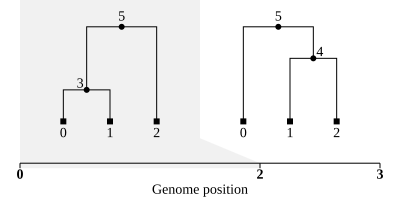

In [20]:
def attempt():
    node_times = (0, 0, 0, 1, 2, 3)
    samples = (0, 1, 2)
    # (p, c, l, r)
    extended_edges = [
        (3, 0, 0, 3),
        (3, 1, 0, 2), 
        (4, 1, 2, 3),
        (4, 2, 0, 3), 
        (5, 3, 0, 3), 
        (5, 4, 0, 3),
    ]
    edges = [
        (3, 0, 0, 2),
        (3, 1, 0, 2), 
        (4, 1, 2, 3),
        (4, 2, 2, 3), 
        (5, 0, 2, 3),
        (5, 2, 0, 2), 
        (5, 3, 0, 2), 
        (5, 4, 2, 3),
    ]
    tables = tskit.TableCollection(sequence_length=3)
    tables.sort()
    for n, t in enumerate(node_times):
        flags = tskit.NODE_IS_SAMPLE if n in samples else 0
        tables.nodes.add_row(time=t, flags=flags)
    for p, c, l, r in edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ts = tables.tree_sequence()
    tables.edges.clear()
    for p, c, l, r in extended_edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ets = tables.tree_sequence()
    assert ts.num_edges == 8
    assert ets.num_edges == 6
    return ts, ets

sattempt, extattempt = attempt()
samples_attempt = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

ancestors_attempt = np.array([
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
 ])

everything_attempt = np.array([
    [0, 1.5, 2.0],  # node 0 at coordinates (1.5, 2.0)
    [1, 4.2, 3.1],  # node 1 at coordinates (4.2, 3.1) 
    [2, 6.6, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [3, 6.8, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [4, 6.9, 5.5],  # node 2 at coordinates (6.7, 5.5)
    [5, 7, 5.5],  # node 2 at coordinates (6.7, 5.5)
])

# unary_indices4 = findUnary(et4)
# getAccOut(t4, unary_indices4, samples4, ancestors4, everything4, "test4_simp")
# getAccOut(et4, unary_indices4, samples4, ancestors4, everything4, "test4_ext")
unary_indices_attempt = findUnary(extattempt)
getAccOut(extattempt, unary_indices_attempt, samples_attempt, ancestors_attempt, everything_attempt, "attempt1")
sattempt.draw_svg()

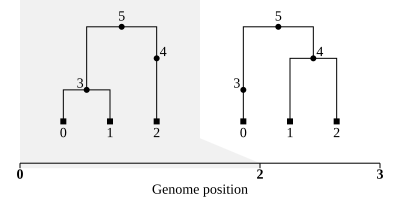

In [17]:
extattempt.draw_svg()

In [9]:
def test_error():
    """
    Example designed to demonstrate high error differences due to unary node extension.
    
    Key features:
    - Node 10 (time 5): Unary node with small interval (3,6) in simplified tree
    - Node 11 (time 7): Unary node with small interval (4,7) in simplified tree
    - Both extend to full genome (0,10) in extended tree
    - Different spatial regions to maximize error
    """
    node_times = (0, 0, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 10)
    samples = (0, 1, 2, 3)


    # Extended tree - unary nodes extended across full genome
    extended_edges = [
        # Node 4 (time 1)
        (4, 0, 0, 10),
        (4, 1, 0, 10),
        # Node 5 (time 2)
        (5, 2, 0, 10),
        (5, 3, 0, 10),
        # Node 6 (time 3)
        (6, 4, 0, 10),
        # Node 7 (time 4)
        (7, 5, 0, 10),
        # Node 10 (time 5) - EXTENDED to full genome
        (10, 6, 0, 10),
        # Node 11 (time 7) - EXTENDED to full genome
        (11, 10, 0, 10),
        # Root (time 10)
        (12, 11, 0, 10),
    ]

    # Simplified tree - edges sorted by parent time (descending), child, left
    edges = [
        # Node 4 (time 1)
        (4, 0, 0, 10),
        (4, 1, 0, 10),
        # Node 5 (time 2)
        (5, 2, 0, 10),
        (5, 3, 0, 10),
        # Node 6 (time 3)
        (6, 4, 0, 10),
        # Node 7 (time 4)
        (7, 5, 0, 10),
        # Node 8 (time 6)
        (8, 6, 0, 3),
        (8, 6, 6, 10),
        # Node 9 (time 8)
        (9, 7, 0, 4),
        (9, 7, 7, 10),
        #(9, 11, 4, 7),
        # Node 10 (time 5) - UNARY with small interval
        (10, 6, 3, 6),
        # Node 11 (time 7) - UNARY with small interval
        (11, 10, 4, 7),
        # Root (time 10)
        (12, 8, 0, 10),
        (12, 9, 0, 10),
    ]
    
    tables = tskit.TableCollection(sequence_length=10)
    tables.sort()
    for n, t in enumerate(node_times):
        flags = tskit.NODE_IS_SAMPLE if n in samples else 0
        tables.nodes.add_row(time=t, flags=flags)
    for p, c, l, r in edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ts = tables.tree_sequence()
    tables.edges.clear()
    for p, c, l, r in extended_edges:
        tables.edges.add_row(parent=p, child=c, left=l, right=r)
    ets = tables.tree_sequence()
    assert ts.num_edges == 14
    assert ets.num_edges == 9
    return ts, ets

# Spatial coordinates designed to maximize error
# Samples in two distinct spatial clusters
test_samples = np.array([
    [0, 2.0, 2.0],   # Cluster 1 (left side)
    [1, 3.0, 2.5],   # Cluster 1 (left side)
    [2, 18.0, 18.0], # Cluster 2 (right side) - far apart!
    [3, 19.0, 18.5], # Cluster 2 (right side)
])

# Ancestors positioned to show the effect of interval changes
test_ancestors = np.array([
    [4, 2.5, 2.2],    # Near samples 0,1
    [5, 18.5, 18.2],  # Near samples 2,3
    [6, 2.8, 2.4],    # Near cluster 1
    [7, 18.3, 18.3],  # Near cluster 2
    [8, 10.0, 10.0],  # Middle (combines both)
    [9, 11.0, 11.0],  # Middle
    [10, 3.0, 3.0],   # In simplified: only sees cluster 1 (interval 3-6)
                       # In extended: sees both clusters (interval 0-10)
    [11, 19.0, 19.0], # In simplified: only sees cluster 2 (interval 4-7)
                       # In extended: sees both clusters (interval 0-10)
    [12, 10.5, 10.5], # Root - middle
])

test_everything = np.array([
    [0, 2.0, 2.0],
    [1, 3.0, 2.5],
    [2, 18.0, 18.0],
    [3, 19.0, 18.5],
    [4, 2.5, 2.2],
    [5, 18.5, 18.2],
    [6, 2.8, 2.4],
    [7, 18.3, 18.3],
    [8, 10.0, 10.0],
    [9, 11.0, 11.0],
    [10, 3.0, 3.0],
    [11, 19.0, 19.0],
    [12, 10.5, 10.5],
])

# Run the analysis
t_high, et_high = test_error()
unary_indices_high = findUnary(et_high)
small_getAccOut(t_high, unary_indices_high, test_samples, test_ancestors, 
          test_everything, "test_high_error_simp")
small_getAccOut(et_high, unary_indices_high, test_samples, test_ancestors, 
          test_everything, "test_high_error_ext")

/home/islar/bradburdlab/tree_project/unary_project/unary_env/lib/python3.12/site-packages/gaiapy/core/quadratic.py:409: RuntimeWarning: invalid value encountered in divide
  optimal_locations[node] = -linear_coeffs / (2 * p0)


,node_id,node_time,error,dist_from_sample_centroid0,dist_from_sample_centroid
0,6.0,3.0,0.036853,10.996022,11.313708
1,7.0,4.0,0.012127,11.209037,11.313708
2,10.0,7.0,0.053023,10.431323,11.313708
3,11.0,8.0,1.383057,12.198873,11.313708
4,12.0,10.0,0.675991,0.250000,11.313708


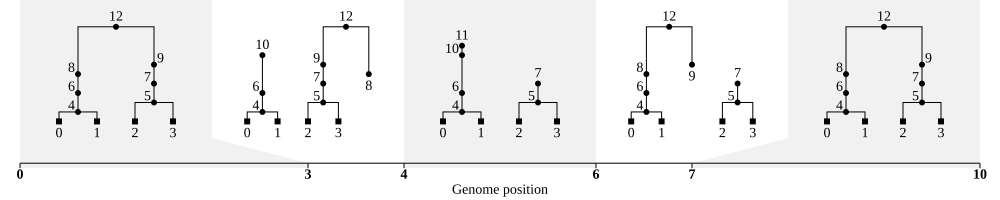

In [10]:
t_high.draw_svg()

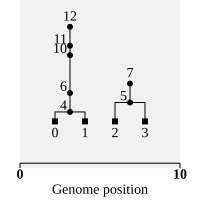

In [11]:
et_high.draw_svg()